In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [27]:
insurance_data = pd.read_csv('insurance.csv')
# Dividing into Inputs and Output
X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]
X["smoker"] = X["smoker"].map({"no": 0, "yes": 1})
# One-Hot Encoding
X = pd.get_dummies(X, columns=["sex", "region"], drop_first=True, dtype=int)
# New Feature
X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]
# Test-Train Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head(3)

,age,bmi,children,smoker,sex_male,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
560,46,19.95,2,0,0,1,0,0,0,0.0
1285,47,24.32,0,0,0,0,0,0,0,0.0
1142,52,24.86,0,0,0,0,1,0,0,0.0


### 1. Lasso

Mean Squared Error for (alpha=0.001): 20922599.871672004
Mean Squared Error for (alpha=0.005): 20922567.59239693
Mean Squared Error for (alpha=0.01): 20922527.331609733
Mean Squared Error for (alpha=0.05): 20922205.299285475
Mean Squared Error for (alpha=0.1): 20921803.73611112
Mean Squared Error for (alpha=0.5): 20918643.689267717
Mean Squared Error for (alpha=1): 20914832.887851413
Mean Squared Error for (alpha=5): 20890881.013139606
Mean Squared Error for (alpha=10): 20872844.87874152
Mean Squared Error for (alpha=25): 20900842.79650422
Mean Squared Error for (alpha=50): 21196930.292785414


<Axes: >

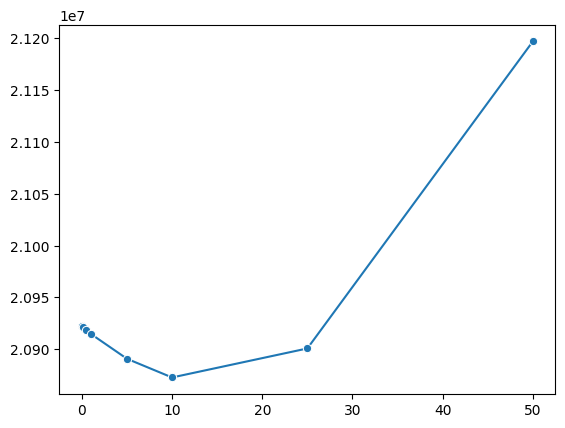

In [34]:
# Lasso Model (finding best alpha value)
alphas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 25, 50]
mse_arr = []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)
    y_pred = lasso_model.predict(X_test)
    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean Squared Error for (alpha={a}): {mse}")
    mse_arr.append(mse)

sns.lineplot(x=alphas, y=mse_arr, marker="o")

### 2. LassoCV

In [29]:
from sklearn.linear_model import LassoCV
alphas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 25, 50]

lasso_cv_model = LassoCV(
    alphas=alphas,
    cv = 5,
    max_iter=1000,
    random_state=42
)
lasso_cv_model.fit(X_train, y_train)
print("Best alpha value: ", lasso_cv_model.alpha_)
# Predict
y_pred = lasso_cv_model.predict(X_test)
# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error: ", mse)
print("R2 value: ", r2)

Best alpha value:  0.001
Mean Squared Error:  20922599.871672004
R2 value:  0.865231749911073


### 3. Ridge Regression

Mean Squared Error for (alpha=0.001): 20922417.54120263
Mean Squared Error for (alpha=0.005): 20921658.15469093
Mean Squared Error for (alpha=0.01): 20920713.85887193
Mean Squared Error for (alpha=0.05): 20913354.111723118
Mean Squared Error for (alpha=0.1): 20904627.38711145
Mean Squared Error for (alpha=0.5): 20851241.0252135
Mean Squared Error for (alpha=1): 20815963.24953625
Mean Squared Error for (alpha=5): 20956035.723328114
Mean Squared Error for (alpha=10): 21236465.19443408
Mean Squared Error for (alpha=25): 21697717.54163343
Mean Squared Error for (alpha=50): 21998664.191644043


<Axes: >

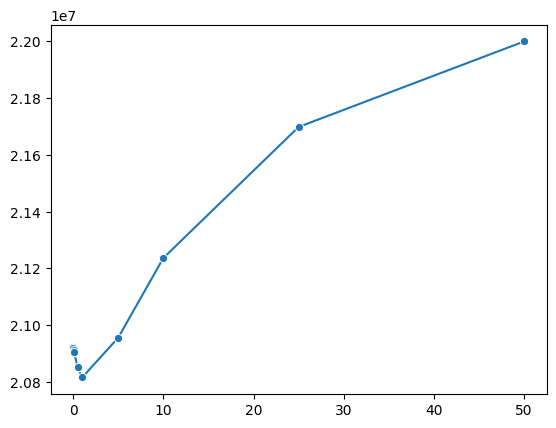

In [35]:
from sklearn.linear_model import Ridge
alphas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 25, 50]
mse_arr = []

for a in alphas:
    ridge_model = Ridge(alpha=a)
    ridge_model.fit(X_train, y_train)
    y_pred = ridge_model.predict(X_test)
    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean Squared Error for (alpha={a}): {mse}")
    mse_arr.append(mse)

sns.lineplot(x=alphas, y=mse_arr, marker="o")

### 4. ElasticNet

Mean Squared Error for (alpha=0.001): 20847773.823439498
Mean Squared Error for (alpha=0.005): 20828876.854007803
Mean Squared Error for (alpha=0.01): 20977471.75661836
Mean Squared Error for (alpha=0.05): 21730251.530155275
Mean Squared Error for (alpha=0.1): 22024611.739723943
Mean Squared Error for (alpha=0.5): 22488194.827391904
Mean Squared Error for (alpha=1): 22654508.40263519
Mean Squared Error for (alpha=5): 23318819.891620267
Mean Squared Error for (alpha=10): 24032342.74940964
Mean Squared Error for (alpha=25): 26005019.236660294
Mean Squared Error for (alpha=50): 28567481.39912954


<Axes: >

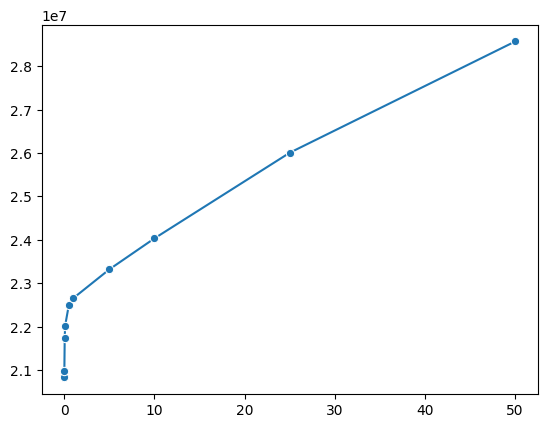

In [40]:
from sklearn.linear_model import ElasticNet
alphas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 25, 50]
mse_arr = []

for a in alphas:
    elastic_model = ElasticNet(alpha=a, l1_ratio=0.5)
    elastic_model.fit(X_train, y_train)
    y_pred = elastic_model.predict(X_test)
    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean Squared Error for (alpha={a}): {mse}")
    mse_arr.append(mse)

sns.lineplot(x=alphas, y=mse_arr, marker="o")